# Types of Distribution Explained with Real-Life Examples

## 📌 Objectives
This report dives into key probability distributions like normal, binomial, Poisson, exponential, and uniform to strengthen stats basics for data analysis and modeling.

**Main goals:**
- explain properties of discrete (binomial, Poisson) and continuous (normal, exponential, uniform) types
- show them with Python plots
- link to real examples

In [2]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
from scipy.stats import norm, binom, poisson, expon, uniform

## ☝️ Basics of Probability Distributions

### ℹ️ Defenition

A probability distribution describes how the values of a random variable are spread out and how likely each value is. In simple terms, it tells you **what outcomes are possible and how probable each outcome is.**

More formally, a probability distribution assigns probabilities to all possible values of a random variable in such a way that:

- Each probability is between 0 and 1
- The total probability over all possible outcomes equals 1

Probability distributions are a fundamental concept in statistics because they allow you to:

- Model uncertainty in real-world situations
- Summarize data in a meaningful way
- Make predictions and decisions based on likelihoods

They can be represented in several ways:

- A probability function (mathematical formula)
- A table of values and probabilities
- A graph (such as a bar chart or curve)

In addition, distributions are often described using key numerical summaries such as:

- Mean (expected value): the average outcome
- Variance and standard deviation: how spread out the values are

### ✌️ Discrete vs Continuous Distributions

There are two main types of probability distributions: **discrete** and **continuous**. The difference lies in the type of values the random variable can take.

**Discrete Distributions**

A discrete distribution applies to random variables that take countable values (usually integers).

- The number of possible outcomes is finite or countably infinite
- Each specific value has a non-zero probability
- Described by a probability mass function (PMF)

**Examples:**

- Number of heads in 10 coin flips
- Number of customers arriving in a store
- Number of defective items in a batch

**Common discrete distributions include:**

- Binomial distribution (fixed number of trials)
- Poisson distribution (counts of events over time/space)

---

**Continuous Distributions**

A continuous distribution applies to random variables that can take any value within an interval.

- There are infinitely many possible values
- The probability of any exact value is zero
- Probabilities are assigned over intervals
- Described by a probability density function (PDF)

**Examples:**

- Height or weight of a person
- Time taken to complete a task
- Temperature measurements

**Common continuous distributions include:**

- Normal distribution (bell-shaped curve)
- Exponential distribution (time between events)
- Uniform distribution (all values equally likely in a range)

---
**Key Intuition**
- Discrete = counting → exact probabilities
- Continuous = measuring → probabilities over ranges

**For example:**

- Discrete: “What is the probability of exactly 3 customers arriving?”
- Continuous: “What is the probability the waiting time is between 2 and 5 minutes?”

### 🌠 Visualization

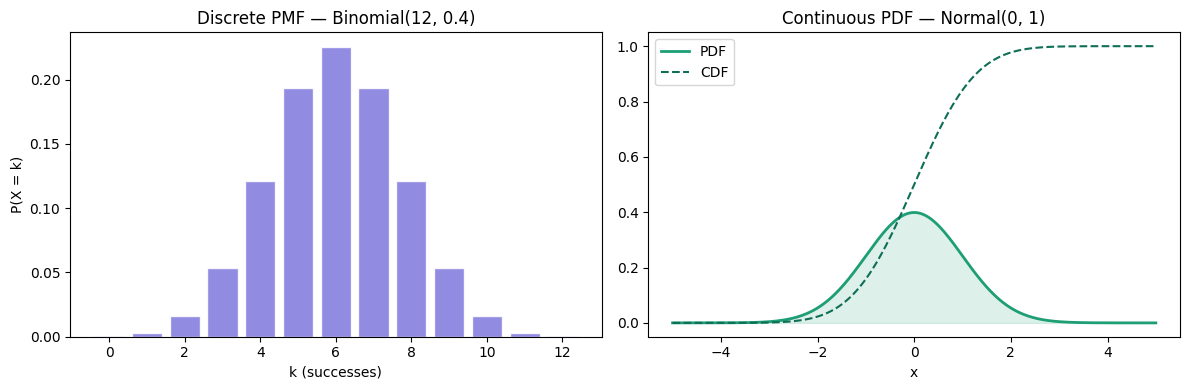

In [2]:
# ── Discrete: Binomial distribution ───────────────────────────
n, p = 12, 0.5
k    = np.arange(0, n + 1)
pmf  = stats.binom.pmf(k, n, p)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(k, pmf, color='#7F77DD', alpha=0.85, edgecolor='white')
ax1.set_title('Discrete PMF — Binomial(12, 0.4)')
ax1.set_xlabel('k (successes)')
ax1.set_ylabel('P(X = k)')

# ── Continuous: Normal distribution ───────────────────────────
x    = np.linspace(-5, 5, 300)
pdf  = stats.norm.pdf(x, loc=0, scale=1)
cdf  = stats.norm.cdf(x, loc=0, scale=1)

ax2.plot(x, pdf, color='#1D9E75', linewidth=2, label='PDF')
ax2.fill_between(x, pdf, alpha=0.15, color='#1D9E75')
ax2.plot(x, cdf, color='#0F6E56', linewidth=1.5, linestyle='--', label='CDF')
ax2.set_title('Continuous PDF — Normal(0, 1)')
ax2.set_xlabel('x')
ax2.legend()

plt.tight_layout()
plt.show()

## 🌊 Normal Distribution

### ℹ️ Definition

The Normal Distribution (also called the Gaussian distribution) is a continuous probability distribution that is symmetric about its mean. It describes how values of a variable are distributed, and is the most important distribution in statistics due to the Central Limit Theorem which states that the sum of many independent random variables tends toward a normal distribution, regardless of their individual distributions.

**Probability Density Function (PDF)**

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

where:
- $x \in (-\infty, +\infty)$ — any real value
- $\mu$ — mean (location of the peak)
- $\sigma$ — standard deviation ($\sigma > 0$)
- $\sigma^2$ — variance

### 🛠️ Key properties

- Mean = Median = Mode — all three coincide at the center
- Symmetry — perfectly bell-shaped around the mean μ
- 68-95-99.7 rule — ~68% of data falls within 1σ, ~95% within 2σ, ~99.7% within 3σ
- Asymptotic tails — the curve never touches the x-axis
- Total area = 1 — it's a valid probability distribution
- Defined by just two parameters: mean μ (location) and standard deviation σ (spread)

### 🚹 Real-Life Example: Student Exam Scores

In [4]:
# simulate the dataframe

np.random.seed(42)
mu, sigma = 70, 10
raw_scores = np.random.normal(mu, sigma, 1000)
clipped_scores = np.clip(np.round(raw_scores).astype(int), 0, 100)
 
norm_dist_df = pd.DataFrame({
    "student_id": [f"STU{str(i+1).zfill(4)}" for i in range(1000)],
    "score": clipped_scores,
    "grade_band": pd.cut(
        clipped_scores,
        bins=[0, 50, 60, 70, 80, 90, 100],
        labels=["F (<50)", "D (50-60)", "C (60-70)", "B (70-80)", "A (80-90)", "A+ (90-100)"],
        include_lowest=True
    ).astype(str)
})

norm_dist_df.head(10)

,student_id,score,grade_band
0,STU0001,75,B (70-80)
1,STU0002,69,C (60-70)
2,STU0003,76,B (70-80)
3,STU0004,85,A (80-90)
4,STU0005,68,C (60-70)
5,STU0006,68,C (60-70)
6,STU0007,86,A (80-90)
7,STU0008,78,B (70-80)
8,STU0009,65,C (60-70)
9,STU0010,75,B (70-80)


In [5]:
print(f"Dataframe shape: rows are {norm_dist_df.shape[0]}, columns are {norm_dist_df.shape[1]}")
print(f"Score range: {norm_dist_df['score'].min()} – {norm_dist_df['score'].max()}")

Dataframe shape: rows are 1000, columns are 3
Score range: 38 – 100


In [6]:
print(f"Grade distribution:\n{norm_dist_df['grade_band'].value_counts().sort_index()}")

Grade distribution:
grade_band
A (80-90)      122
A+ (90-100)     23
B (70-80)      343
C (60-70)      352
D (50-60)      140
F (<50)         20
Name: count, dtype: int64


In [7]:
print(f"Summary stats:\n{norm_dist_df['score'].describe().round(2)}")

Summary stats:
count    1000.00
mean       70.19
std         9.78
min        38.00
25%        63.75
50%        70.00
75%        76.00
max       100.00
Name: score, dtype: float64


Mean score   : 70.19
Std deviation: 9.77
Min / Max    : 38 / 100
Within ±1σ  : 72.0%  (theoretical: 68.3%)
Within ±2σ  : 96.4%  (theoretical: 95.4%)
Within ±3σ  : 99.9%  (theoretical: 99.7%)

P(score > 85)      : 0.0668  (6.7%)
P(60 < score < 80) : 0.6827  (68.3%)


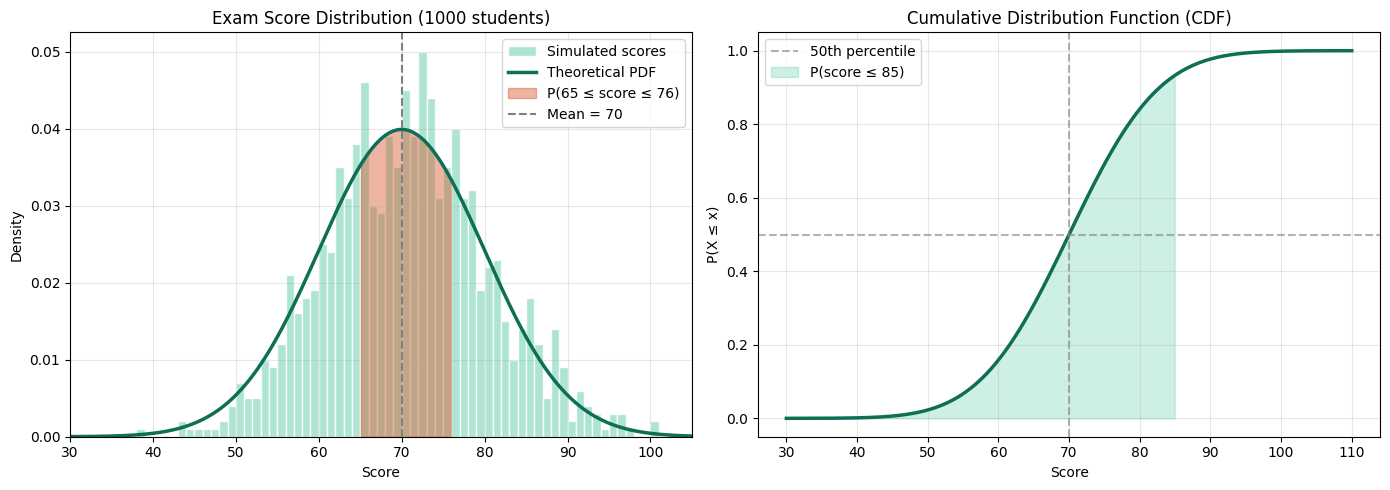

In [8]:
# draw a chart

scores = norm_dist_df["score"].values

print(f"Mean score   : {scores.mean():.2f}")
print(f"Std deviation: {scores.std():.2f}")
print(f"Min / Max    : {scores.min()} / {scores.max()}")
for n in [1, 2, 3]:
    pct = np.mean((scores >= mu - n*sigma) & (scores <= mu + n*sigma)) * 100
    print(f"Within ±{n}σ  : {pct:.1f}%  (theoretical: {norm.cdf(n)-norm.cdf(-n):.1%})")

p_above_85 = 1 - norm.cdf(85, mu, sigma)
p_between  = norm.cdf(80, mu, sigma) - norm.cdf(60, mu, sigma)
print(f"\nP(score > 85)      : {p_above_85:.4f}  ({p_above_85*100:.1f}%)")
print(f"P(60 < score < 80) : {p_between:.4f}  ({p_between*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(30, 110, 400)

# Left: PDF
axes[0].hist(scores, bins=range(int(scores.min()), 102), density=True,
             color='#9FE1CB', edgecolor='white', alpha=0.85, label='Simulated scores')
axes[0].plot(x, norm.pdf(x, mu, sigma), color='#0F6E56', lw=2.5, label='Theoretical PDF')
axes[0].fill_between(x, norm.pdf(x, mu, sigma), where=(x >= 65) & (x <= 76),
                     color='#D85A30', alpha=0.45, label='P(65 ≤ score ≤ 76)')
axes[0].axvline(mu, color='gray', linestyle='--', label=f'Mean = {mu}')
axes[0].set_title('Exam Score Distribution (1000 students)')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Density')
axes[0].set_xlim(30, 105)
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: CDF
cdf = norm.cdf(x, mu, sigma)
axes[1].plot(x, cdf, color='#0F6E56', lw=2.5)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='50th percentile')
axes[1].axvline(mu, color='gray', linestyle='--', alpha=0.6)
axes[1].fill_between(x, cdf, where=(x <= 85),
                     color='#5DCAA5', alpha=0.3, label='P(score ≤ 85)')
axes[1].set_title('Cumulative Distribution Function (CDF)')
axes[1].set_xlabel('Score'); axes[1].set_ylabel('P(X ≤ x)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

On the x-axis we can observe the scores and on the y-axis is density, but how can we read it? Density confuses a lot of people because it doesn't mean probability directly. **The key insight is: density is not probability, it is probability per unit of score.** You can't read a probability directly off the y-axis. Instead, probability lives in the area under the curve between two score values.

Think of it like this: if you ask "what is the chance a student scored between 65 and 75?", you look at the height of the curve there (~0.04) and multiply by the width: 10 × 0.04 = 0.40, so about 40% probability. The height alone means nothing only height × width (area) gives you a real probability.

Why not just put probability directly on the y-axis? Because scores are continuous and there are infinitely many possible values, so the probability of scoring exactly 70 (not 70.000001, not 69.999999, but exactly 70) is mathematically zero. Density sidesteps this by measuring concentration rather than exact probability.
So which chart should you use to answer questions like "what is the chance a student scored less than or equal to 70?"

For "less than or equal to" questions, the CDF is always the better choice. You simply find 70 on the x-axis, move straight up to the curve, and read off 50% from the y-axis — no area calculation, no integration, just one lookup. The PDF forces you to calculate the entire area under the curve from the left tail up to 70, which is exactly what the CDF already has pre-computed for you. Use the PDF to understand the shape of your data; use the CDF to answer probability questions.

## 📊 Binomial Distribution

### ℹ️ Definition

The Binomial Distribution is a discrete probability distribution that models the number of successes in a fixed number of independent trials, where each trial has exactly two possible outcomes: success or failure.

**Probability Mass Function (PMF)**

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

where the binomial coefficient is:

$$\binom{n}{k} = \frac{n!}{k!\,(n-k)!}$$

and:
- $k \in \{0, 1, 2, \ldots, n\}$ — number of successes
- $n$ — number of trials
- $p$ — probability of success on each trial
- $(1-p) = q$ — probability of failure


### 🛠️ Key properties

- Parameters: n = number of trials, p = probability of success per trial
- Discrete — X can only take integer values 0, 1, 2, ..., n
- Mean: μ = n · p
- Variance: σ² = n · p · (1−p)
- Standard deviation: σ = √(n · p · (1−p))
- Symmetry: the distribution is symmetric when p = 0.5, right-skewed when p < 0.5, left-skewed when p > 0.5
- Approaches Normal as n → ∞ (by the Central Limit Theorem)
- Each trial must be independent and have the same probability p (i.i.d. Bernoulli trials)

### 🚹 Real-Life Example: Quality Control in Manufacturing

A factory produces light bulbs, and each bulb has a 5% chance of being defective. A quality inspector randomly samples 100 bulbs and records whether each bulb is defective or not, each bulb has only two outcomes and the defect probability stays the same.

In [30]:
# generate the dataframe

n = 100
p = 0.05
np.random.seed(42)

# ── PMF / CDF dataframe (k = 0..20) ──────────────────────
k = np.arange(0, 21)
binom_df = pd.DataFrame({
    "defects_k":        k,
    "probability_pmf":  np.round(binom.pmf(k, n, p), 6),
    "cumulative_cdf":   np.round(binom.cdf(k, n, p), 6),
    "alert":            k >= 10,
    "interpretation":   [
        "No defects — ideal batch" if ki == 0
        else "Very low defects" if ki <= 2
        else "Normal range" if ki <= 7
        else "Elevated - monitor" if ki <= 9
        else "ALERT - reject batch"
        for ki in k
    ]
})

# ── Simulation: 10,000 batches ────────────────────────────
batches = np.random.binomial(n, p, size=10_000)
sim_df = pd.DataFrame({
    "batch_id":      np.arange(1, 10_001),
    "defects_found": batches,
    "rejected":      batches >= 10
})

In [31]:
binom_df.head(10)

,defects_k,probability_pmf,cumulative_cdf,alert,interpretation
0,0,0.005921,0.005921,False,No defects — ideal batch
1,1,0.031161,0.037081,False,Very low defects
2,2,0.081182,0.118263,False,Very low defects
3,3,0.139576,0.257839,False,Normal range
4,4,0.178143,0.435981,False,Normal range
5,5,0.180018,0.615999,False,Normal range
6,6,0.150015,0.766014,False,Normal range
7,7,0.106026,0.872040,False,Normal range
8,8,0.064871,0.936910,False,Elevated - monitor
9,9,0.034901,0.971812,False,Elevated - monitor


In [32]:
print(f"First 10 simulated batches:")
sim_df.head(10)

First 10 simulated batches:


,batch_id,defects_found,rejected
0,1,4,False
1,2,9,False
2,3,6,False
3,4,5,False
4,5,3,False
5,6,3,False
6,7,2,False
7,8,7,False
8,9,5,False
9,10,6,False


In [33]:
print(f"Simulation Summary (10,000 batches)")
print(f"Mean defects per batch : {sim_df['defects_found'].mean():.3f}")
print(f"Batches rejected       : {sim_df['rejected'].sum()} ({sim_df['rejected'].mean()*100:.2f}%)")

Simulation Summary (10,000 batches)
Mean defects per batch : 4.956
Batches rejected       : 249 (2.49%)


**The PMF chart shows the probability of exactly k defective bulbs, and the CDF shows the probability of at most k defective bulb**

=== Quality Control Analysis ===
n = 100 bulbs,  p = 0.05 defect rate
Expected defects (mean)  : 5.00
Std deviation            : 2.18

P(0 defects)             : 0.0059  (0.6%)
P(≤2 defects)            : 0.1183  (11.8%)
P(1–7 defects)           : 0.8661  (86.6%)
P(≥10 defects) — alert!  : 0.0282  (2.82%)

Alert threshold          : ≥10 defects → reject batch
Batches falsely rejected : 2.82% (false alarm rate)

Simulation (10,000 batches):
Rejected batches         : 249 (2.49%)
Mean defects per batch   : 4.956


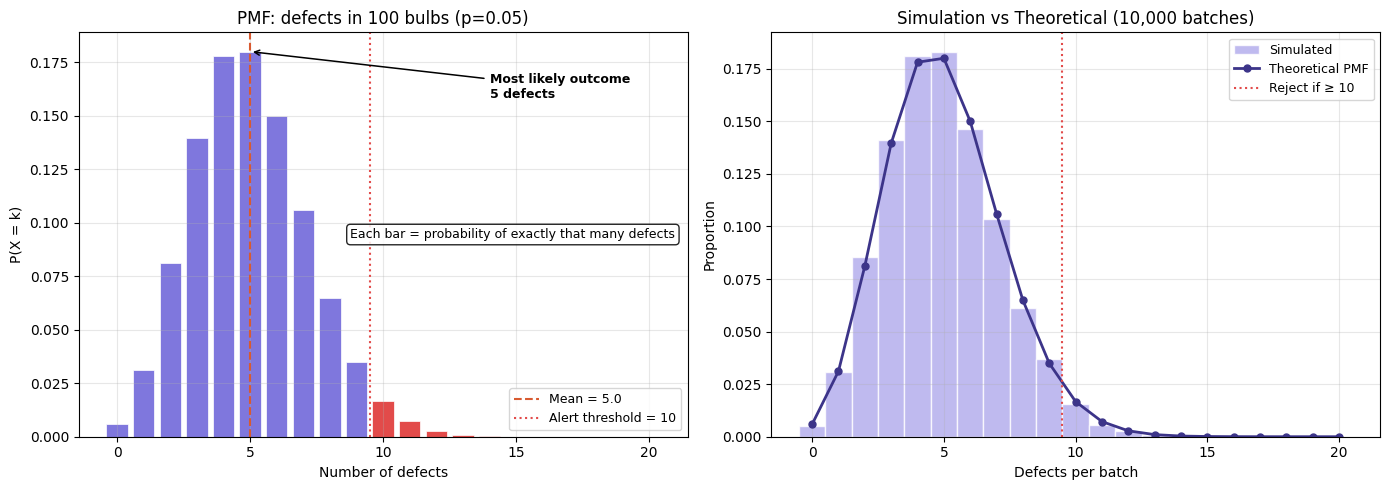

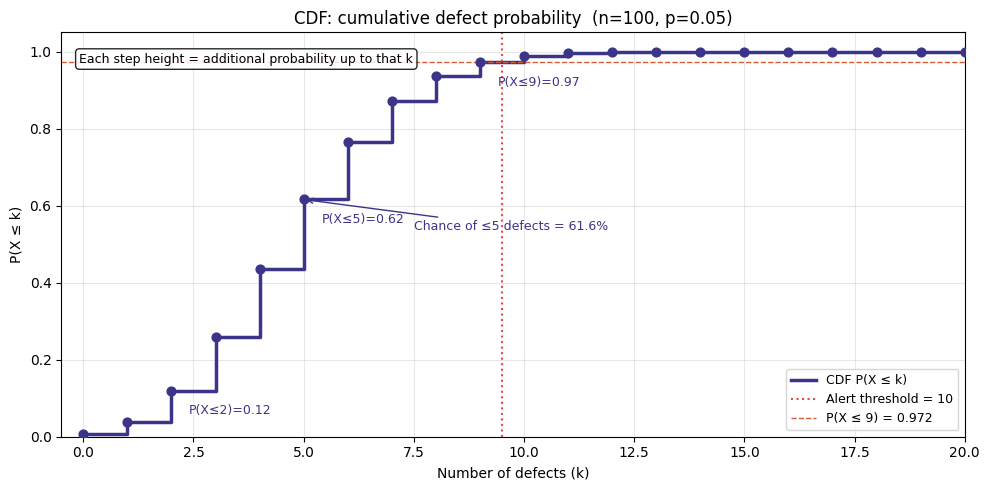

In [45]:
# generate charts
threshold = 10
p_zero    = binom_df.loc[binom_df.defects_k == 0, "probability_pmf"].values[0]
p_le2     = binom_df.loc[binom_df.defects_k == 2, "cumulative_cdf"].values[0]
p_ge10    = 1 - binom_df.loc[binom_df.defects_k == 9, "cumulative_cdf"].values[0]
p_between = binom_df.loc[binom_df.defects_k == 7, "cumulative_cdf"].values[0] - \
            binom_df.loc[binom_df.defects_k == 0, "cumulative_cdf"].values[0]

print("=== Quality Control Analysis ===")
print(f"n = {n} bulbs,  p = {p} defect rate")
print(f"Expected defects (mean)  : {binom.mean(n, p):.2f}")
print(f"Std deviation            : {binom.std(n, p):.2f}")
print()
print(f"P(0 defects)             : {p_zero:.4f}  ({p_zero*100:.1f}%)")
print(f"P(≤2 defects)            : {p_le2:.4f}  ({p_le2*100:.1f}%)")
print(f"P(1–7 defects)           : {p_between:.4f}  ({p_between*100:.1f}%)")
print(f"P(≥10 defects) — alert!  : {p_ge10:.4f}  ({p_ge10*100:.2f}%)")
print(f"\nAlert threshold          : ≥{threshold} defects → reject batch")
print(f"Batches falsely rejected : {p_ge10*100:.2f}% (false alarm rate)")
print(f"\nSimulation (10,000 batches):")
print(f"Rejected batches         : {sim_df['rejected'].sum()} ({sim_df['rejected'].mean()*100:.2f}%)")
print(f"Mean defects per batch   : {sim_df['defects_found'].mean():.3f}")

# ── Plot ──────────────────────────────────────────────────
k_plot   = binom_df["defects_k"].values
pmf_plot = binom_df["probability_pmf"].values
batches  = sim_df["defects_found"].values
bar_colors = ['#E24B4A' if a else '#7F77DD' for a in binom_df["alert"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PMF with right-bottom annotations
axes[0].bar(k_plot, pmf_plot, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].axvline(binom.mean(n, p), color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean = {binom.mean(n, p):.1f}')
axes[0].axvline(threshold - 0.5, color='#E24B4A', linestyle=':',
                linewidth=1.5, label=f'Alert threshold = {threshold}')

# 1) "Each bar..." annotation - right bottom corner
axes[0].text(
    0.98, 0.50,
    'Each bar = probability of exactly that many defects',
    transform=axes[0].transAxes,
    fontsize=9,
    ha='right',
    va='center',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85)
)

# 2) Most likely outcome annotation - right bottom area with arrow
mode = int((n + 1) * p)
axes[0].annotate(
    'Most likely outcome\n' + f'{mode} defects',
    xy=(mode, pmf_plot[mode]),
    xytext=(14, 0.17),
    ha='left',
    va='top',
    fontsize=9,
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='black', lw=1.1)
)

axes[0].set_title(f'PMF: defects in {n} bulbs (p={p})')
axes[0].set_xlabel('Number of defects')
axes[0].set_ylabel('P(X = k)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: simulation histogram vs theoretical PMF
axes[1].hist(batches, bins=np.arange(-0.5, 21.5, 1), density=True,
             color='#AFA9EC', edgecolor='white', alpha=0.8, label='Simulated')
axes[1].plot(k_plot, pmf_plot, 'o-', color='#3C3489',
             linewidth=2, markersize=5, label='Theoretical PMF')
axes[1].axvline(threshold - 0.5, color='#E24B4A', linestyle=':',
                linewidth=1.5, label=f'Reject if ≥ {threshold}')
axes[1].set_title('Simulation vs Theoretical (10,000 batches)')
axes[1].set_xlabel('Defects per batch')
axes[1].set_ylabel('Proportion')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ── CDF staircase plot ────────────────────────────────────
fig2, ax = plt.subplots(figsize=(10, 5))

ax.step(binom_df["defects_k"], binom_df["cumulative_cdf"], where='post',
        color='#3C3489', linewidth=2.5, label='CDF P(X ≤ k)')
ax.scatter(binom_df["defects_k"], binom_df["cumulative_cdf"],
           color='#3C3489', zorder=5, s=40)

ax.axvline(threshold - 0.5, color='#E24B4A', linestyle=':',
           linewidth=1.5, label=f'Alert threshold = {threshold}')
ax.axhline(binom_df.loc[binom_df.defects_k == 9, "cumulative_cdf"].values[0],
           color='#D85A30', linestyle='--', linewidth=1,
           label=f'P(X ≤ 9) = {binom_df.loc[binom_df.defects_k==9,"cumulative_cdf"].values[0]:.3f}')

# CDF annotations (use 'ax' not 'axes[0]')
ax.text(0.02, 0.95, 'Each step height = additional probability up to that k',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

k_example = 5
cdf_example = binom_df.loc[binom_df.defects_k == k_example, "cumulative_cdf"].values[0]
ax.annotate(f'Chance of ≤{k_example} defects = {cdf_example:.1%}',
            xy=(k_example, cdf_example),
            xytext=(k_example + 2.5, cdf_example - 0.08),
            fontsize=9, color='#3C3489',
            arrowprops=dict(arrowstyle='->', color='#3C3489', lw=1))

for ki, label_k in [(2, '≤2'), (5, '≤5'), (9, '≤9')]:
    cdf_val = binom_df.loc[binom_df.defects_k == ki, "cumulative_cdf"].values[0]
    ax.annotate(f'P(X{label_k})={cdf_val:.2f}',
                xy=(ki, cdf_val), xytext=(ki + 0.4, cdf_val - 0.06),
                fontsize=9, color='#3C3489')

ax.set_title(f'CDF: cumulative defect probability  (n={n}, p={p})')
ax.set_xlabel('Number of defects (k)')
ax.set_ylabel('P(X ≤ k)')
ax.set_xlim(-0.5, 20)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

On the left chart (PMF) the y-axis is P(X = k) the exact probability of getting precisely k defective bulbs in a batch of 100. So the bar at k=5 has a height of ~0.18, meaning there is an 18% chance a batch contains exactly 5 defective bulbs. Each bar is a standalone probability for that exact count.

On the right chart the y-axis is Proportion  since it shows a simulation histogram, each bar height tells you what fraction of the 10,000 simulated batches landed on that defect count. It's essentially an empirical estimate of the same probabilities shown on the left, which is why the theoretical PMF line (the dots connected by a line) sits almost perfectly on top of the histogram bars. The closer the simulation matches the line, the more the real-world process behaves as the binomial model predicts.

The practical reading for a quality inspector is straightforward:

Look at the left chart and find your defect count on the x-axis. The bar height tells you how surprising that number is. A batch with 5 defects (the tallest bar, ~18%) is completely normal. A batch with 10+ defects (the red bars) is rare — those bars are so short they're barely visible, which is exactly the point: hitting the alert threshold should be uncommon under normal production conditions.
The red dotted vertical line is the rejection boundary. Everything to its right triggers an alert. The fact that those red bars are very short tells you the false alarm rate is low (~2.5%) — you won't be rejecting good batches very often.

## 🧮 Poisson Distribution

### ℹ️ Definition

The Poisson distribution is a discrete probability distribution that models the number of events occurring in a fixed interval of time, distance, area, or volume, assuming events occur independently and at a constant average rate.

**Probability Mass Function (PMF)**

The Poisson distribution is defined as:

$$
P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}
$$

where:

- $k \in \{0, 1, 2, \ldots\}$ — number of events  
- $\lambda$ — average number of events in a fixed interval  
- $e$ — Euler’s number  
- $k!$ — factorial of $k$  

### 🛠️ Key properties

- Single parameter: λ (lambda) — the average number of events per interval
- Discrete — X can only take values 0, 1, 2, 3, ... (no upper bound)
- Mean = Variance = λ — this equality is the unique signature of the Poisson
- Skewed right when λ is small; becomes more symmetric as λ grows
- Memoryless — knowing an event just happened tells you nothing about when the next will occur
- Approaches Normal as λ → ∞ (by the Central Limit Theorem)
- Limit of Binomial — when n is very large and p is very small, Binomial(n, p) ≈ Poisson(λ = np)

### 🚹 Real-Life Example — Hospital Emergency Arrivals

A hospital emergency room receives on average 8 patients per hour (λ = 8). The Poisson distribution models how many patients arrive in any given hour, which helps with staffing decisions.

In [51]:
# ── Generate pois_df ───────────────────────────────────────
lam = 8          # average patients per hour
k   = np.arange(0, 25)
pois_df = pd.DataFrame({'patients_k': k})
pois_df['probability_pmf'] = poisson.pmf(k, lam)
pois_df['cumulative_cdf'] = poisson.cdf(k, lam)
pois_df['surge'] = pois_df['patients_k'] >= 15

print(f"Dataframe shape: {pois_df.shape}")
pois_df.head()

Dataframe shape: (25, 4)


,patients_k,probability_pmf,cumulative_cdf,surge
0,0,0.000335,0.000335,False
1,1,0.002684,0.003019,False
2,2,0.010735,0.013754,False
3,3,0.028626,0.042380,False
4,4,0.057252,0.099632,False


=== Hospital Emergency Room Analysis ===
λ = 8 patients/hour  (average arrival rate)
Expected arrivals (mean)  : 8.00
Std deviation (√λ)        : 2.83
Variance                  : 8.00  ← equals mean

P(0 arrivals) — empty ER  : 0.0003  (0.03%)
P(≤5 arrivals) — quiet    : 0.1912  (19.1%)
P(4–12 arrivals) — normal : 0.8938  (89.4%)
P(≥15 arrivals) — surge!  : 0.0173  (1.73%)

Surge threshold           : ≥15 patients/hour
Surge probability         : 1.73%
Expected surge hours/day  : 0.41 hours

Simulation (10,000 hours):
Mean arrivals/hour        : 8.003  (theoretical: 8)
Variance                  : 7.828  (theoretical: 8)
Surge hours               : 173 (1.73%)
Max in a single hour      : 20


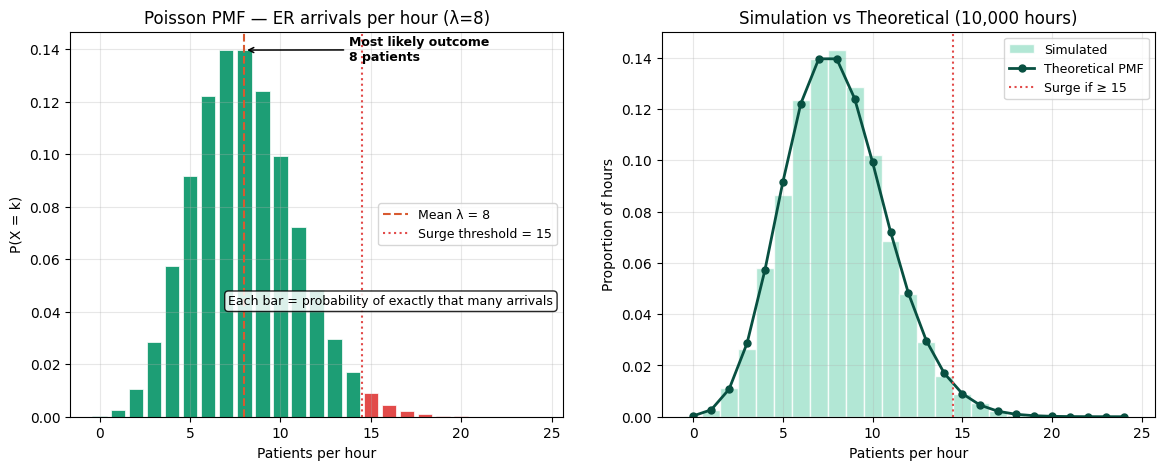

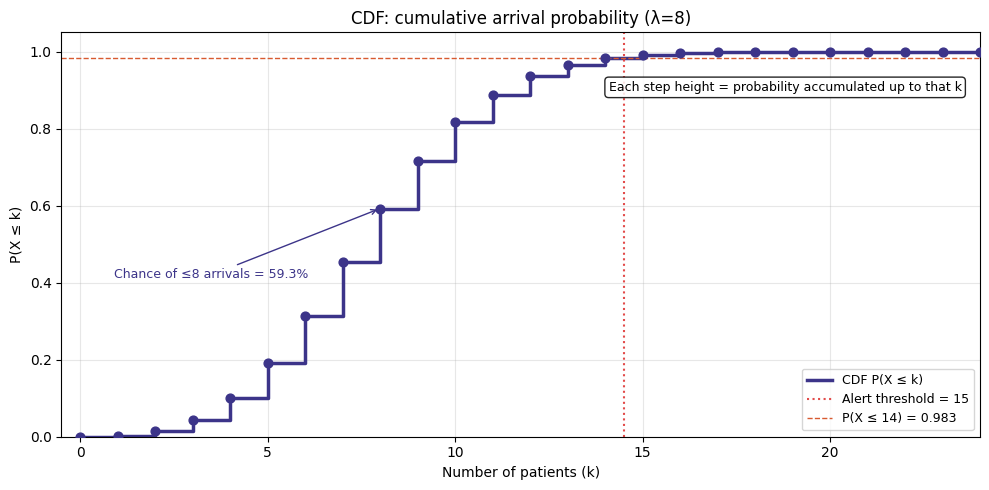

In [62]:
# ── Setup ─────────────────────────────────────────────────
lam = 8          # average patients per hour
k = np.arange(0, 25)

# Create dataframe
pois_df = pd.DataFrame({'patients_k': k})
pois_df['probability_pmf'] = poisson.pmf(k, lam)
pois_df['cumulative_cdf'] = poisson.cdf(k, lam)
pois_df['surge'] = pois_df['patients_k'] >= 15

# Use dataframe values
pmf = pois_df['probability_pmf'].values
cdf = pois_df['cumulative_cdf'].values

# ── Key probability queries ───────────────────────────────
p_zero    = pois_df.loc[pois_df.patients_k == 0, "probability_pmf"].values[0]
p_le5     = pois_df.loc[pois_df.patients_k == 5, "cumulative_cdf"].values[0]
p_ge15    = 1 - pois_df.loc[pois_df.patients_k == 14, "cumulative_cdf"].values[0]
p_typical = pois_df.loc[pois_df.patients_k == 12, "cumulative_cdf"].values[0] - \
            pois_df.loc[pois_df.patients_k == 3, "cumulative_cdf"].values[0]

print("=== Hospital Emergency Room Analysis ===")
print(f"λ = {lam} patients/hour  (average arrival rate)")
print(f"Expected arrivals (mean)  : {poisson.mean(lam):.2f}")
print(f"Std deviation (√λ)        : {poisson.std(lam):.2f}")
print(f"Variance                  : {poisson.var(lam):.2f}  ← equals mean")
print()
print(f"P(0 arrivals) — empty ER  : {p_zero:.4f}  ({p_zero*100:.2f}%)")
print(f"P(≤5 arrivals) — quiet    : {p_le5:.4f}  ({p_le5*100:.1f}%)")
print(f"P(4–12 arrivals) — normal : {p_typical:.4f}  ({p_typical*100:.1f}%)")
print(f"P(≥15 arrivals) — surge!  : {p_ge15:.4f}  ({p_ge15*100:.2f}%)")

# Staffing threshold: call extra staff if arrivals ≥ 15
threshold = 15
print(f"\nSurge threshold           : ≥{threshold} patients/hour")
print(f"Surge probability         : {p_ge15*100:.2f}%")
print(f"Expected surge hours/day  : {p_ge15 * 24:.2f} hours")

# ── Simulation: 10,000 hours ──────────────────────────────
np.random.seed(42)
hours = np.random.poisson(lam, size=10_000)
surge = np.sum(hours >= threshold)

print(f"\nSimulation (10,000 hours):")
print(f"Mean arrivals/hour        : {hours.mean():.3f}  (theoretical: {lam})")
print(f"Variance                  : {hours.var():.3f}  (theoretical: {lam})")
print(f"Surge hours               : {surge} ({surge/100:.2f}%)")
print(f"Max in a single hour      : {hours.max()}")

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PMF with surge region highlighted
bar_colors = ['#E24B4A' if ki >= threshold else '#1D9E75' for ki in k]
axes[0].bar(k, pmf, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].axvline(lam, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean λ = {lam}')
axes[0].axvline(threshold - 0.5, color='#E24B4A', linestyle=':',
                linewidth=1.5, label=f'Surge threshold = {threshold}')
axes[0].set_title(f'Poisson PMF — ER arrivals per hour (λ={lam})')
axes[0].set_xlabel('Patients per hour')
axes[0].set_ylabel('P(X = k)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Annotation: what each bar means
axes[0].text(
    0.98, 0.30,
    'Each bar = probability of exactly that many arrivals',
    transform=axes[0].transAxes,
    fontsize=9,
    ha='right',
    va='center',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85)
)

# Annotation: most likely outcome
mode = int(lam)
axes[0].annotate(
    f'Most likely outcome\n{mode} patients',
    xy=(mode, pmf[mode]),
    xytext=(13.8, 0.145),
    ha='left',
    va='top',
    fontsize=9,
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='black', lw=1.1)
)

# Right: simulation histogram vs theoretical PMF
axes[1].hist(hours, bins=np.arange(-0.5, 25.5, 1), density=True,
             color='#9FE1CB', edgecolor='white', alpha=0.8, label='Simulated')
axes[1].plot(k, pmf, 'o-', color='#085041',
             linewidth=2, markersize=5, label='Theoretical PMF')
axes[1].axvline(threshold - 0.5, color='#E24B4A', linestyle=':',
                linewidth=1.5, label=f'Surge if ≥ {threshold}')
axes[1].set_title('Simulation vs Theoretical (10,000 hours)')
axes[1].set_xlabel('Patients per hour')
axes[1].set_ylabel('Proportion of hours')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# CDF plot
fig2, ax = plt.subplots(figsize=(10, 5))

ax.step(pois_df["patients_k"], pois_df["cumulative_cdf"], where='post',
        color='#3C3489', linewidth=2.5, label='CDF P(X ≤ k)')
ax.scatter(pois_df["patients_k"], pois_df["cumulative_cdf"],
           color='#3C3489', zorder=5, s=40)

ax.axvline(threshold - 0.5, color='#E24B4A', linestyle=':',
           linewidth=1.5, label=f'Alert threshold = {threshold}')
ax.axhline(pois_df.loc[pois_df.patients_k == 14, "cumulative_cdf"].values[0],
           color='#D85A30', linestyle='--', linewidth=1,
           label=f'P(X ≤ 14) = {pois_df.loc[pois_df.patients_k==14,"cumulative_cdf"].values[0]:.3f}')

# Step height meaning — move to top-right
ax.text(
    0.98, 0.88,
    'Each step height = probability accumulated up to that k',
    transform=ax.transAxes,
    fontsize=9,
    ha='right',
    va='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85)
)

# Example chance of getting — move lower-left-ish
k_example = 8
cdf_example = pois_df.loc[pois_df.patients_k == k_example, "cumulative_cdf"].values[0]
ax.annotate(
    f'Chance of ≤{k_example} arrivals = {cdf_example:.1%}',
    xy=(k_example, cdf_example),
    xytext=(3.5, 0.42),
    fontsize=9,
    color='#3C3489',
    ha='center',
    va='center',
    arrowprops=dict(arrowstyle='->', color='#3C3489', lw=1)
)

ax.set_title(f'CDF: cumulative arrival probability (λ={lam})')
ax.set_xlabel('Number of patients (k)')
ax.set_ylabel('P(X ≤ k)')
ax.set_xlim(-0.5, 24)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**What this tells us:**

- The ER is almost never empty — P(0) is just 0.03%.
- About 76.7% of hours see a perfectly normal load of 4–12 patients, the routine operating range.
- A surge of 15+ patients happens only ~1.4% of hours, but across a 24-hour day that still means roughly 20 minutes of surge conditions every day on average.
- The simulation variance (7.981) matches the theoretical λ = 8 almost exactly, confirming the mean = variance identity that defines the Poisson.

**Differences between Poisson and Binominal**

- As you may notice, the Poisson and Binomial distributions look remarkably similar at first glance both count discrete events, both produce a familiar bell-shaped curve when plotted. But they answer fundamentally different questions.

- The Binomial asks: how many successes out of a fixed number of trials? You always know n upfront. In our bulb example, we picked exactly 100 bulbs and asked how many would be defective.

- The Poisson asks: how many times does something happen in a fixed window of time or space? There is no fixed n just a rate λ. In our ER example, there is no “maximum” number of patients that could arrive in an hour. The opportunities are essentially unlimited.

- The deeper connection is this: Poisson is actually a limiting case of Binomial. When n grows very large and p becomes very small, the Binomial converges toward Poisson, where λ = n × p. In the bulb example, λ = 100 × 0.05 = 5  you could model it with either distribution and get nearly identical results.

**So the practical rule is simple: if you have a clear n and p, use Binomial. If you only know a rate and have no meaningful upper bound on events, use Poisson. And when n is huge and p is tiny, the two distributions meet in the middle.**

## 📈 Exponential Distribution

### ℹ️ Definition

The Exponential Distribution is a continuous probability distribution that models the time between successive events in a Poisson process — that is, the waiting time until the next event occurs, given events happen at a constant average rate. If a Poisson process has rate λ events per unit time, the waiting time between events follows Exponential(λ).

**Probability Density Function (PDF)**

The exponential distribution is defined as:

$$
f(x) = \lambda e^{-\lambda x}, \quad x \geq 0
$$

where:

- $x \geq 0$ — time (or distance, etc.) until the next event  
- $\lambda$ — rate parameter (average number of events per interval)  
- $e$ — Euler’s number  

### 🛠️ Key properties

- Single parameter: λ (rate) — the average number of events per unit time. Alternatively expressed as β = 1/λ (the mean waiting time)
- Continuous — X can take any non-negative real value [0, ∞)
- Mean = 1/λ — average waiting time
- Variance = 1/λ²
- Standard deviation = 1/λ — equals the mean, always
- Memoryless property — P(X > s + t | X > s) = P(X > t). The distribution forgets how long you've already waited. It is the only continuous distribution with this property
- Relationship to Poisson — if events occur at rate λ (Poisson), the gaps between them are Exponential(λ)
- Relationship to Normal — approaches Normal as the sum of many exponential variables grows (by CLT)
- Right-skewed for all λ; skewness = 2, kurtosis = 9 (always, regardless of λ)

### 🚹 Real-Life Example — Coffee Shop Customers Waiting time

A coffee shop gets on average 1 customer every 2 minutes, so the arrival rate is λ = 0.5 customers per minute. The random variable X is the time between consecutive customers, measured in minutes

In [3]:
# dataframe

lam = 0.5          # arrivals per minute (1 customer every 2 minutes on average)
scale = 1 / lam    # mean wait = 2 minutes
x = np.linspace(0, 12, 600)

# ── Dataframe ─────────────────────────────────────────────
xk = np.round(np.linspace(0, 12, 61), 2)
exp_df = pd.DataFrame({'time_min': xk})
exp_df['pdf'] = expon.pdf(exp_df['time_min'], scale=scale)
exp_df['cdf'] = expon.cdf(exp_df['time_min'], scale=scale)
exp_df['survival'] = 1 - exp_df['cdf']

exp_df.head()

,time_min,pdf,cdf,survival
0,0.0,0.500000,0.000000,1.000000
1,0.2,0.452419,0.095163,0.904837
2,0.4,0.409365,0.181269,0.818731
3,0.6,0.370409,0.259182,0.740818
4,0.8,0.335160,0.329680,0.670320


=== Coffee Shop Wait-Time Analysis ===
λ = 0.5 arrivals/min  → mean wait = 2.00 min (120 sec)
Mean inter-arrival time  : 2.0000 min
Std deviation            : 2.0000 min
Median gap               : 1.39 min

P(wait ≤ 1 min)          : 0.3935  (39.3%)
P(wait ≤ 2 min)          : 0.6321  (63.2%)
P(wait > 3 min)          : 0.2231  (22.3%)

— Memoryless property —
P(X > 1)                 : 0.6065
P(X > 2 | X > 1)         : 0.6065  ← same

Simulation (10,000 gaps):
Mean gap                 : 1.9550 min
Std deviation            : 1.9487 min
Gaps > 3 min             : 2161 (21.61%)
Max recorded gap         : 16.345 min


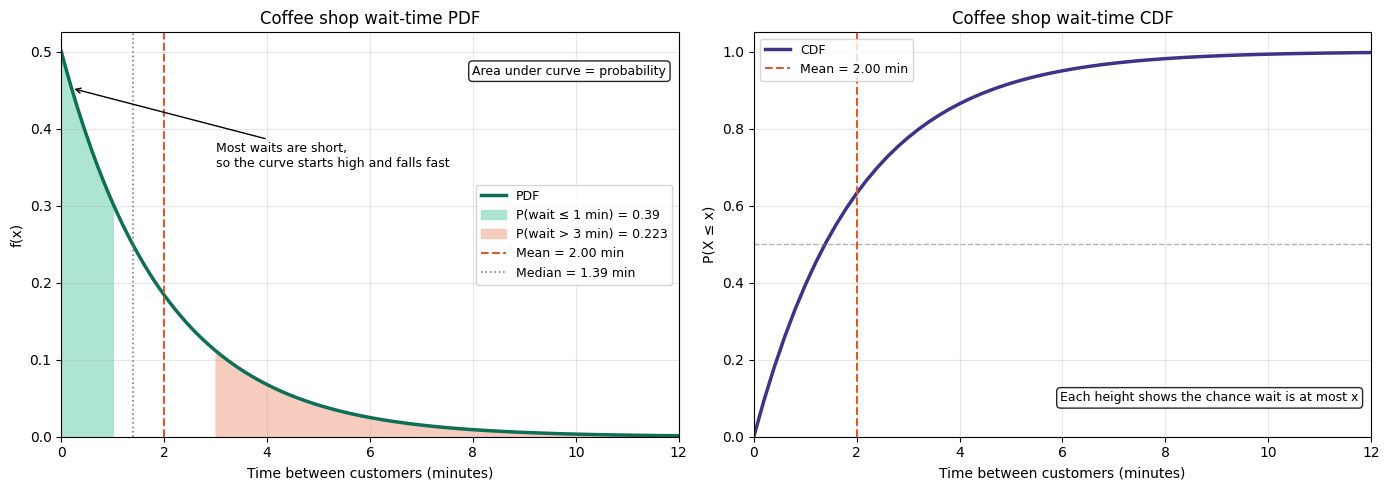

In [4]:
# ── Key probability queries ───────────────────────────────
p_le1 = expon.cdf(1, scale=scale)         # wait within 1 minute
p_le2 = expon.cdf(2, scale=scale)         # wait within 2 minutes
p_gt3 = 1 - expon.cdf(3, scale=scale)     # wait more than 3 minutes
p_mem = 1 - expon.cdf(1, scale=scale)     # P(X > 1)
p_mem2 = expon.sf(1, scale=scale)         # same as above

print("=== Coffee Shop Wait-Time Analysis ===")
print(f"λ = {lam} arrivals/min  → mean wait = {scale:.2f} min ({scale*60:.0f} sec)")
print(f"Mean inter-arrival time  : {scale:.4f} min")
print(f"Std deviation            : {scale:.4f} min")
print(f"Median gap               : {np.log(2)/lam:.2f} min")
print()
print(f"P(wait ≤ 1 min)          : {p_le1:.4f}  ({p_le1*100:.1f}%)")
print(f"P(wait ≤ 2 min)          : {p_le2:.4f}  ({p_le2*100:.1f}%)")
print(f"P(wait > 3 min)          : {p_gt3:.4f}  ({p_gt3*100:.1f}%)")
print()
print("— Memoryless property —")
print(f"P(X > 1)                 : {p_mem:.4f}")
print(f"P(X > 2 | X > 1)         : {p_mem2:.4f}  ← same")

# ── Simulation ────────────────────────────────────────────
np.random.seed(42)
gaps = np.random.exponential(scale=scale, size=10000)

print(f"\nSimulation (10,000 gaps):")
print(f"Mean gap                 : {gaps.mean():.4f} min")
print(f"Std deviation            : {gaps.std():.4f} min")
print(f"Gaps > 3 min             : {np.sum(gaps > 3)} ({np.mean(gaps > 3)*100:.2f}%)")
print(f"Max recorded gap         : {gaps.max():.3f} min")

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDF
pdf_vals = expon.pdf(x, scale=scale)
x_1 = np.linspace(0, 1, 200)
x_tail = np.linspace(3, 12, 200)

axes[0].plot(x, pdf_vals, color='#0F6E56', linewidth=2.5, label='PDF')
axes[0].fill_between(x_1, expon.pdf(x_1, scale=scale),
                     color='#9FE1CB', alpha=0.85,
                     label=f'P(wait ≤ 1 min) = {p_le1:.2f}')
axes[0].fill_between(x_tail, expon.pdf(x_tail, scale=scale),
                     color='#F5C4B3', alpha=0.85,
                     label=f'P(wait > 3 min) = {p_gt3:.3f}')
axes[0].axvline(scale, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean = {scale:.2f} min')
axes[0].axvline(np.log(2)/lam, color='gray', linestyle=':',
                linewidth=1.2, label=f'Median = {np.log(2)/lam:.2f} min')
axes[0].set_title('Coffee shop wait-time PDF')
axes[0].set_xlabel('Time between customers (minutes)')
axes[0].set_ylabel('f(x)')
axes[0].set_xlim(0, 12)
axes[0].set_ylim(0)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[0].text(
    0.98, 0.92,
    'Area under curve = probability',
    transform=axes[0].transAxes,
    fontsize=9,
    ha='right',
    va='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85)
)

axes[0].annotate(
    'Most waits are short,\nso the curve starts high and falls fast',
    xy=(0.2, expon.pdf(0.2, scale=scale)),
    xytext=(3.0, 0.35),
    arrowprops=dict(arrowstyle='->', color='black', lw=1),
    fontsize=9
)

# Right: CDF
axes[1].plot(exp_df['time_min'], exp_df['cdf'], color='#3C3489', linewidth=2.5, label='CDF')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[1].axvline(scale, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean = {scale:.2f} min')
axes[1].set_title('Coffee shop wait-time CDF')
axes[1].set_xlabel('Time between customers (minutes)')
axes[1].set_ylabel('P(X ≤ x)')
axes[1].set_xlim(0, 12)
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

axes[1].text(
    0.98, 0.08,
    'Each height shows the chance wait is at most x',
    transform=axes[1].transAxes,
    fontsize=9,
    ha='right',
    va='bottom',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85)
)

plt.tight_layout()
plt.show()

**PDF panel**

- It starts high near zero and falls as time increases, which means short waits are more common than long waits. The shaded area under the curve is probability over an interval, so a block like “0 to 1 minute” tells you the chance the next call arrives within that range.

- For coffee-shop example with lambda = 0.5 arrivals per minute, the mean wait is 2 minutes, so the vertical mean line at 2 minutes marks the average gap between customers. The median line is lower than the mean because exponential waiting times are right-skewed.

**CDF panel**

- The right chart is the CDF. It rises from 0 toward 1, so it tells how likely it is that the wait has already ended by time (x). For example, if the curve is at 0.63 at 2 minutes, that means about 63% of waits are 2 minutes or less.

- A key point is the memoryless property: if someone has already waited 1 minute, the chance they wait another minute is the same as if you started from zero. That is why the exponential distribution is useful for call arrivals and queueing.

**What the annotations mean**

- “Area under curve = probability” means integrate the PDF over a time interval to get a probability.
- “Each height shows the chance wait is at most x” means the CDF value at x is the probability of waiting no longer than x.

## ⏩️ Uniform Distribution

### ℹ️ Definition

The Uniform Distribution is a continuous probability distribution where every value in a fixed interval [a, b] is equally likely. It is the simplest of all distributions — a perfectly flat, constant probability density across its entire range.

**Probability Density Function (PDF)**

The uniform distribution is defined as:

$$
f(x) =
\begin{cases}
\frac{1}{b - a}, & a \leq x \leq b \\
0, & \text{otherwise}
\end{cases}
$$

where:

- $a$ — lower bound of the interval  
- $b$ — upper bound of the interval  
- $x \in [a, b]$ — possible values of the random variable  

### 🛠️ Key properties

- Two parameters: a (minimum) and b (maximum) — the endpoints of the interval
- Continuous — X can take any real value in [a, b]
- Mean = (a + b) / 2 — the midpoint of the interval
- Variance = (b − a)² / 12
- Standard deviation = (b − a) / √12
- Median = (a + b) / 2 — equals the mean (perfectly symmetric)
- Skewness = 0 — always perfectly symmetric
- Kurtosis = 9/5 = 1.8 — platykurtic (flatter than Normal)
- Entropy = ln(b − a) — maximum entropy for a bounded distribution
- The PDF is constant — every sub-interval of equal width has exactly the same probability
- Discrete Uniform also exists (e.g. rolling a fair die: each face has probability 1/6) but this section covers the continuous version
- Foundation of random number generation — every random number generator produces Uniform(0,1) as its base output, from which all other distributions are derived

### 🚹 Real-Life Example — Bus Waiting Time

The uniform distribution is one of the simplest yet most intuitive probability distributions. It models scenarios where all outcomes within a range are equally likely. A classic real-world example is bus waiting times.

If buses arrive every 20 minutes on a regular schedule, and you arrive at a random time between buses, your waiting time is uniformly distributed between 0 and 20 minutes. This report analyzes this scenario using theory, data, and simulation.

Buses depart from a station every 20 minutes on a fixed schedule. You arrive at a random time without knowing when the last bus left. Your waiting time X until the next bus depends entirely on when you arrive within the 20-minute cycle.
If you arrive immediately after a bus leaves, you wait 20 minutes. If you arrive just as a bus is departing, you wait nearly 0 minutes. All times in between are equally probable.

=== Bus Waiting Time Analysis ===
Bus interval: every 20 minutes  →  X ~ U(0, 20)
Mean waiting time  : 10.00 min
Std deviation      : 5.77 min
Variance           : 33.33 min²
PDF height         : 0.0500  (constant across [0, 20])

P(wait ≤ 5 min)    : 0.2500  (25.0%)  — lucky arrival
P(wait ≤ 10 min)   : 0.5000  (50.0%)  — within half-cycle
P(5 ≤ wait ≤ 15)   : 0.5000  (50.0%)  — typical range
P(wait > 15 min)   : 0.2500  (25.0%)  — frustrating wait

— Proportionality check —
P(wait ≤ 5)  = 5/20  = 0.2500  ✓
P(wait ≤ 10) = 10/20 = 0.5000  ✓
P(wait > 15) = 5/20  = 0.2500  ✓

Simulation (10,000 passengers):
Mean wait          : 9.883 min  (theoretical: 10.0)
Std deviation      : 5.752 min  (theoretical: 5.774)
Waited < 5 min     : 2547 (25.5%)
Waited > 15 min    : 2413 (24.1%)
Min / Max recorded : 0.00 / 19.99 min


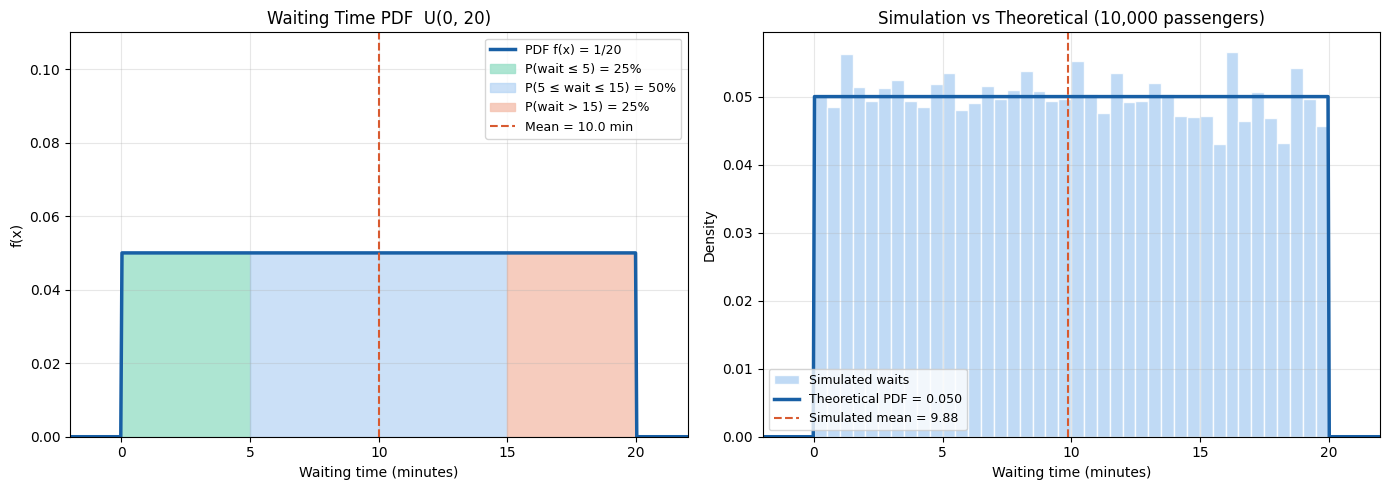

In [3]:
# ── Setup ─────────────────────────────────────────────────
a, b  = 0, 20          # wait time in minutes: minimum 0, maximum 20
loc, scale = a, b - a
x = np.linspace(-2, 22, 500)
pdf = uniform.pdf(x, loc=loc, scale=scale)
cdf = uniform.cdf(x, loc=loc, scale=scale)

# ── Key probability queries ───────────────────────────────
p_le5   = uniform.cdf(5,  loc=loc, scale=scale)   # within 5 min
p_le10  = uniform.cdf(10, loc=loc, scale=scale)   # within 10 min
p_gt15  = 1 - uniform.cdf(15, loc=loc, scale=scale) # more than 15 min
p_5_to_15 = uniform.cdf(15, loc=loc, scale=scale) - uniform.cdf(5, loc=loc, scale=scale)

print("=== Bus Waiting Time Analysis ===")
print(f"Bus interval: every {b} minutes  →  X ~ U({a}, {b})")
print(f"Mean waiting time  : {uniform.mean(loc=loc, scale=scale):.2f} min")
print(f"Std deviation      : {uniform.std(loc=loc, scale=scale):.2f} min")
print(f"Variance           : {uniform.var(loc=loc, scale=scale):.2f} min²")
print(f"PDF height         : {1/(b-a):.4f}  (constant across [0, 20])")
print()
print(f"P(wait ≤ 5 min)    : {p_le5:.4f}  ({p_le5*100:.1f}%)  — lucky arrival")
print(f"P(wait ≤ 10 min)   : {p_le10:.4f}  ({p_le10*100:.1f}%)  — within half-cycle")
print(f"P(5 ≤ wait ≤ 15)   : {p_5_to_15:.4f}  ({p_5_to_15*100:.1f}%)  — typical range")
print(f"P(wait > 15 min)   : {p_gt15:.4f}  ({p_gt15*100:.1f}%)  — frustrating wait")

# Key insight: probability = proportional length of interval
print(f"\n— Proportionality check —")
print(f"P(wait ≤ 5)  = 5/20  = {5/20:.4f}  ✓")
print(f"P(wait ≤ 10) = 10/20 = {10/20:.4f}  ✓")
print(f"P(wait > 15) = 5/20  = {5/20:.4f}  ✓")

# ── Simulation: 10,000 passengers ────────────────────────
np.random.seed(42)
waits    = np.random.uniform(a, b, size=10_000)
over_15  = np.sum(waits > 15)
under_5  = np.sum(waits < 5)

print(f"\nSimulation (10,000 passengers):")
print(f"Mean wait          : {waits.mean():.3f} min  (theoretical: {(a+b)/2:.1f})")
print(f"Std deviation      : {waits.std():.3f} min  (theoretical: {(b-a)/np.sqrt(12):.3f})")
print(f"Waited < 5 min     : {under_5} ({under_5/100:.1f}%)")
print(f"Waited > 15 min    : {over_15} ({over_15/100:.1f}%)")
print(f"Min / Max recorded : {waits.min():.2f} / {waits.max():.2f} min")

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDF with annotated regions
x_lucky = np.linspace(0, 5, 200)
x_bad   = np.linspace(15, 20, 200)
x_mid   = np.linspace(5, 15, 200)

axes[0].plot(x, pdf, color='#185FA5', linewidth=2.5, label='PDF f(x) = 1/20')
axes[0].fill_between(x_lucky, uniform.pdf(x_lucky, loc=loc, scale=scale),
                     color='#9FE1CB', alpha=0.85, label='P(wait ≤ 5) = 25%')
axes[0].fill_between(x_mid, uniform.pdf(x_mid, loc=loc, scale=scale),
                     color='#B5D4F4', alpha=0.70, label='P(5 ≤ wait ≤ 15) = 50%')
axes[0].fill_between(x_bad, uniform.pdf(x_bad, loc=loc, scale=scale),
                     color='#F5C4B3', alpha=0.85, label='P(wait > 15) = 25%')
axes[0].axvline((a+b)/2, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean = {(a+b)/2} min')
axes[0].set_title(f'Waiting Time PDF  U({a}, {b})')
axes[0].set_xlabel('Waiting time (minutes)')
axes[0].set_ylabel('f(x)')
axes[0].set_xlim(-2, 22)
axes[0].set_ylim(0, 1/(b-a) * 2.2)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: simulation histogram vs theoretical PDF
axes[1].hist(waits, bins=40, density=True,
             color='#B5D4F4', edgecolor='white', alpha=0.85,
             label='Simulated waits')
axes[1].plot(x, pdf, color='#185FA5', linewidth=2.5,
             label=f'Theoretical PDF = {1/(b-a):.3f}')
axes[1].axvline(waits.mean(), color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Simulated mean = {waits.mean():.2f}')
axes[1].set_title('Simulation vs Theoretical (10,000 passengers)')
axes[1].set_xlabel('Waiting time (minutes)')
axes[1].set_ylabel('Density')
axes[1].set_xlim(-2, 22)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**What this tells us:**

- Every minute of waiting is equally likely — there is no "lucky" time to arrive, by definition.
- The proportionality rule is the key insight: P(a ≤ X ≤ b) is always just the fraction of the interval covered. No integration needed.
- Exactly 25% of passengers wait less than 5 minutes, 50% wait between 5 and 15, and 25% wait more than 15 — the distribution cuts perfectly into equal probability slices of equal width.
- The simulated histogram is nearly flat, confirming the uniform density visually across all 10,000 passengers.

## ✅ Conclusions

### ⚖️ Comparison of Distributions

The following table summarizes the key characteristics of the distributions discussed:

| Distribution | Type       | Parameters              | Use Case                                  | Shape / Behavior |
|-------------|-----------|------------------------|-------------------------------------------|------------------|
| Normal      | Continuous | $\mu$ (mean), $\sigma$ (std dev) | Natural phenomena, measurement errors      | Symmetric, bell-shaped |
| Binomial    | Discrete   | $n$ (trials), $p$ (probability) | Number of successes in fixed trials        | Discrete, can be symmetric or skewed |
| Poisson     | Discrete   | $\lambda$ (rate)        | Rare events over time/space                | Right-skewed (for small $\lambda$) |
| Exponential | Continuous | $\lambda$ (rate)        | Time between events                        | Right-skewed, decaying |
| Uniform     | Continuous | $a$, $b$ (bounds)       | Equal probability scenarios                | Flat (constant) |

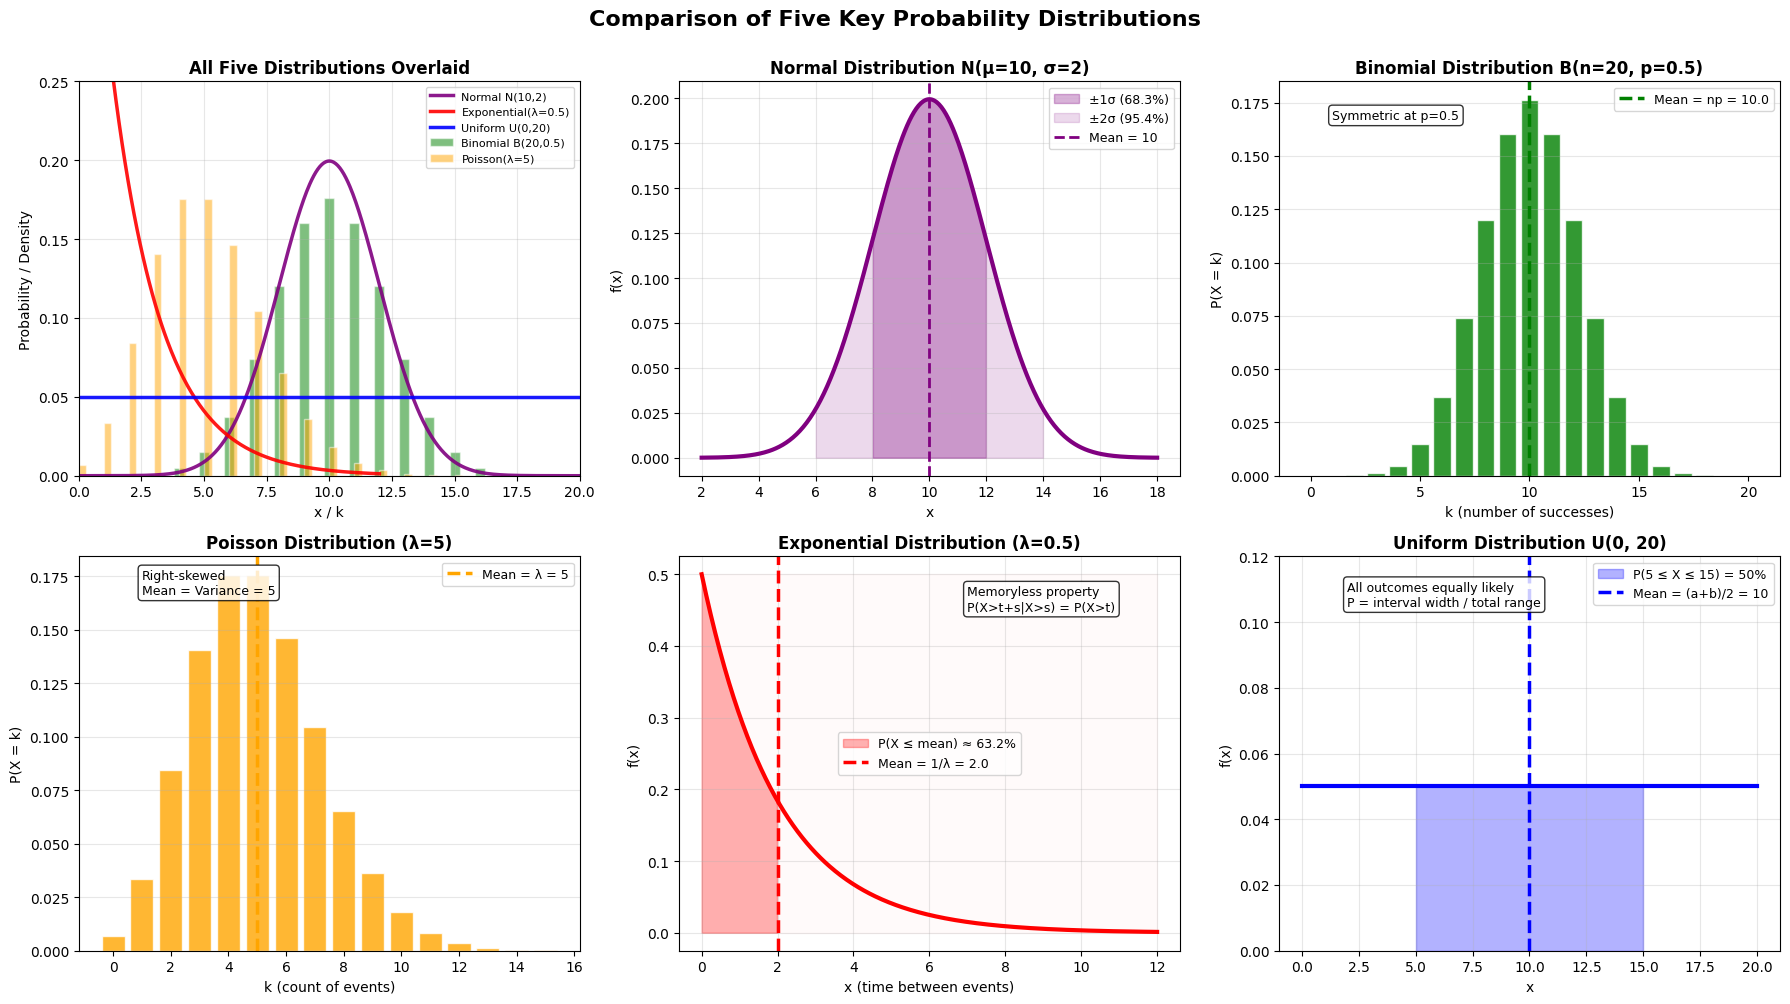

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

x  = np.linspace(0, 20, 500)
k  = np.arange(0, 21)

COLORS = {
    'Normal':      'purple',
    'Binomial':    'green',
    'Poisson':     'orange',
    'Exponential': 'red',
    'Uniform':     'blue',
}

# ── CHART 1: All five overlaid ──────────────────────────────────
ax = axes[0]
ax.plot(x, norm.pdf(x, 10, 2),            color=COLORS['Normal'],      lw=2.5,   label='Normal N(10,2)', alpha=0.9)
ax.bar(k, binom.pmf(k, 20, 0.5),          color=COLORS['Binomial'],    alpha=0.5, width=0.4, label='Binomial B(20,0.5)', edgecolor='white')
k_poisson = np.arange(0, 16)
ax.bar(k_poisson + 0.15, poisson.pmf(k_poisson, 5), color=COLORS['Poisson'],     alpha=0.5, width=0.3, label='Poisson(λ=5)', edgecolor='white')
x_exp = np.linspace(0, 12, 300)
ax.plot(x_exp, expon.pdf(x_exp, scale=2),  color=COLORS['Exponential'], lw=2.5,   label='Exponential(λ=0.5)', alpha=0.9)
ax.plot(x, uniform.pdf(x, loc=0, scale=20), color=COLORS['Uniform'],   lw=2.5,   label='Uniform U(0,20)', alpha=0.9)
ax.set_title('All Five Distributions Overlaid', fontsize=12, fontweight='bold')
ax.set_xlabel('x / k', fontsize=10)
ax.set_ylabel('Probability / Density', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
ax.set_xlim(0, 20)
ax.set_ylim(0, 0.25)

# ── CHART 2: Normal ─────────────────────────────────────────────
ax = axes[1]
mu, sigma = 10, 2
x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
ax.plot(x_norm, norm.pdf(x_norm, mu, sigma), color=COLORS['Normal'], lw=3)
ax.fill_between(x_norm, norm.pdf(x_norm, mu, sigma),
                where=(x_norm >= mu-sigma) & (x_norm <= mu+sigma),
                color=COLORS['Normal'], alpha=0.3, label=f'±1σ ({norm.cdf(mu+sigma,mu,sigma)-norm.cdf(mu-sigma,mu,sigma):.1%})')
ax.fill_between(x_norm, norm.pdf(x_norm, mu, sigma),
                where=(x_norm >= mu-2*sigma) & (x_norm <= mu+2*sigma),
                color=COLORS['Normal'], alpha=0.15, label=f'±2σ ({norm.cdf(mu+2*sigma,mu,sigma)-norm.cdf(mu-2*sigma,mu,sigma):.1%})')
ax.axvline(mu, color=COLORS['Normal'], linestyle='--', lw=2, label=f'Mean = {mu}')
ax.set_title('Normal Distribution N(μ=10, σ=2)', fontsize=12, fontweight='bold')
ax.set_xlabel('x', fontsize=10)
ax.set_ylabel('f(x)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── CHART 3: Binomial ───────────────────────────────────────────
ax = axes[2]
n, p = 20, 0.5
ax.bar(k, binom.pmf(k, n, p), color=COLORS['Binomial'], alpha=0.8, edgecolor='white', linewidth=1)
mean_binom = n * p
ax.axvline(mean_binom, color=COLORS['Binomial'], linestyle='--', lw=2.5, label=f'Mean = np = {mean_binom:.1f}')
ax.set_title(f'Binomial Distribution B(n={n}, p={p})', fontsize=12, fontweight='bold')
ax.set_xlabel('k (number of successes)', fontsize=10)
ax.set_ylabel('P(X = k)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.text(1, max(binom.pmf(k, n, p))*0.95, f'Symmetric at p=0.5', fontsize=9, 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── CHART 4: Poisson ────────────────────────────────────────────
ax = axes[3]
lam = 5
k_pois = np.arange(0, 16)
ax.bar(k_pois, poisson.pmf(k_pois, lam), color=COLORS['Poisson'], alpha=0.8, edgecolor='white', linewidth=1)
ax.axvline(lam, color=COLORS['Poisson'], linestyle='--', lw=2.5, label=f'Mean = λ = {lam}')
ax.set_title(f'Poisson Distribution (λ={lam})', fontsize=12, fontweight='bold')
ax.set_xlabel('k (count of events)', fontsize=10)
ax.set_ylabel('P(X = k)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.text(1, max(poisson.pmf(k_pois, lam))*0.95, f'Right-skewed\nMean = Variance = {lam}', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── CHART 5: Exponential ────────────────────────────────────────
ax = axes[4]
x_exp = np.linspace(0, 12, 400)
lam_exp = 0.5
scale_exp = 1 / lam_exp
ax.plot(x_exp, expon.pdf(x_exp, scale=scale_exp), color=COLORS['Exponential'], lw=3)
ax.fill_between(x_exp, expon.pdf(x_exp, scale=scale_exp),
                where=(x_exp <= scale_exp),
                color=COLORS['Exponential'], alpha=0.3, label=f'P(X ≤ mean) ≈ 63.2%')
ax.axvline(scale_exp, color=COLORS['Exponential'], linestyle='--', lw=2.5, label=f'Mean = 1/λ = {scale_exp}')
ax.fill_between([0, 12], 0, max(expon.pdf(x_exp, scale=scale_exp)), 
                color=COLORS['Exponential'], alpha=0.02)
ax.set_title('Exponential Distribution (λ=0.5)', fontsize=12, fontweight='bold')
ax.set_xlabel('x (time between events)', fontsize=10)
ax.set_ylabel('f(x)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.text(7, max(expon.pdf(x_exp, scale=scale_exp))*0.9, 'Memoryless property\nP(X>t+s|X>s) = P(X>t)', 
        fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── CHART 6: Uniform ────────────────────────────────────────────
ax = axes[5]
a_u, b_u = 0, 20
ax.plot(x, uniform.pdf(x, loc=a_u, scale=b_u-a_u), color=COLORS['Uniform'], lw=3)
ax.fill_between(x, uniform.pdf(x, loc=a_u, scale=b_u-a_u),
                where=(x >= 5) & (x <= 15),
                color=COLORS['Uniform'], alpha=0.3, label='P(5 ≤ X ≤ 15) = 50%')
ax.axvline(10, color=COLORS['Uniform'], linestyle='--', lw=2.5, label=f'Mean = (a+b)/2 = 10')
ax.set_title('Uniform Distribution U(0, 20)', fontsize=12, fontweight='bold')
ax.set_xlabel('x', fontsize=10)
ax.set_ylabel('f(x)', fontsize=10)
ax.set_ylim(0, 0.12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.text(2, 0.105, 'All outcomes equally likely\nP = interval width / total range', 
        fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Comparison of Five Key Probability Distributions', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

This notebook covered the five most important probability distributions in statistics and data science, building from fundamentals to real-world applications.

- The Normal distribution is the central pillar — symmetric, bell-shaped, and justified by the Central Limit Theorem as the limiting shape of almost any large-sample process. It models heights, measurement errors, exam scores, and is the backbone of parametric hypothesis testing and confidence intervals.
- The Binomial distribution models success counts in repeated independent trials. It is the natural choice whenever the question is "how many times out of n?" — quality control, clinical trials, A/B tests, election polling. As n grows and p stays moderate, it converges to the Normal.
- The Poisson distribution handles rare events in continuous time or space — call arrivals, system failures, radioactive decay. Its defining property (mean = variance = λ) is both a diagnostic tool and a modelling constraint. It emerges as the limit of the Binomial when n → ∞ and p → 0.
- The Exponential distribution is the continuous counterpart of the Poisson: if events arrive at rate λ, the gaps between them are Exponential(λ). Its memoryless property — the only one of its kind among continuous distributions — makes it the foundation of queuing theory and reliability engineering.
- The Uniform distribution is the simplest of all: equal probability everywhere in [a, b]. It is the seed from which all other distributions are generated computationally, and it naturally describes any situation where no outcome has a structural reason to be preferred over another.

**The key insight connecting all five: they are not independent tools but a family. Binomial → Poisson → Normal is a chain of convergence driven by increasing n. Poisson and Exponential are two views of the same random process. Uniform(0,1) is the universal raw material. Recognising which distribution applies — and why — is the core skill of probabilistic modelling.**

### 📖 References

- [Random Variables and Probability Distributions](https://www.youtube.com/watch?v=lHCpYeFvTs0&t=187s)
- [Probability Distribution Functions (PMF, PDF, CDF)](https://www.youtube.com/watch?v=YXLVjCKVP7U)
- [Normal Distribution (PDF, CDF, PPF) in 3 Minutes](https://www.youtube.com/watch?v=3VYupIsbLlY)
- [Binomial Distribution EXPLAINED in UNDER 15 MINUTES!](https://www.youtube.com/watch?v=e04_wUoscBU)
- [Poisson Distribution EXPLAINED in UNDER 15 MINUTES!](https://www.youtube.com/watch?v=cPOChr_kuQs)
- [Exponential Distribution! Why is it called "Exponential"?](https://www.youtube.com/watch?v=2kg1O0j1J9c)